# Trabajo Grupal - Análisis de datos - 2026 B1

## Grupo 4 - Eventos de Violencia Organizada
- Pedro Ignacio Rubiolo
- Lourdes Sofia Tolotto
- Manuel Dieguez
- Santiago Federico Bettig
## Secciones
- Inicio
- EDA
- Visualizacion
- Plantear Problema de ML
- Preprocesamiento y Limpieza
- Feature Engineering
- Reduccion de Dimensionalidad

## Inicio

In [480]:
#Imports
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import geodatasets
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from category_encoders import HashingEncoder
from sklearn.compose import ColumnTransformer

In [481]:
#Config
pd.set_option('display.max_columns', None)

In [482]:
#Carga del dataset completo
df = pd.read_csv("GEDEvent_v25_1.csv")

/tmp/ipykernel_11562/4152491008.py:2: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("GEDEvent_v25_1.csv")


## EDA

### Objetivos
- Cargar el dataset proporcionado y realizar un análisis exploratorio de los datos. 
- Describir las características principales del dataset, incluyendo el número de 
observaciones, número de variables y tipos de datos. 
- Identificar patrones generales y distribuciones.  
- Identificar errores, outliers (anomalías), valores faltantes y su tipo (MCAR, MAR, 
MNAR). 

In [483]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385918 entries, 0 to 385917
Data columns (total 49 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 385918 non-null  int64  
 1   relid              385918 non-null  object 
 2   year               385918 non-null  int64  
 3   active_year        385918 non-null  bool   
 4   code_status        385918 non-null  object 
 5   type_of_violence   385918 non-null  int64  
 6   conflict_dset_id   385918 non-null  int64  
 7   conflict_new_id    385918 non-null  int64  
 8   conflict_name      385918 non-null  object 
 9   dyad_dset_id       385918 non-null  int64  
 10  dyad_new_id        385918 non-null  int64  
 11  dyad_name          385918 non-null  object 
 12  side_a_dset_id     385918 non-null  int64  
 13  side_a_new_id      385918 non-null  int64  
 14  side_a             385918 non-null  object 
 15  side_b_dset_id     385918 non-null  int64  
 16  si

In [484]:
df.head()

,id,relid,year,active_year,code_status,type_of_violence,conflict_dset_id,conflict_new_id,conflict_name,dyad_dset_id,dyad_new_id,dyad_name,side_a_dset_id,side_a_new_id,side_a,side_b_dset_id,side_b_new_id,side_b,number_of_sources,source_article,source_office,source_date,source_headline,source_original,where_prec,where_coordinates,where_description,adm_1,adm_2,latitude,longitude,geom_wkt,priogrid_gid,country,country_id,region,event_clarity,date_prec,date_start,date_end,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnoa,gwnob
0,244657,IRQ-2017-1-524-322,2017,True,Clear,1,259,259,Iraq: Government,524,524,Government of Iraq - IS,116,116,Government of Iraq,234,234,IS,3,"""Agence France Presse,2017-08-01,At least 20 k...",Agence France Presse;Agence France Presse;Pajh...,2017-08-01;2017-08-01;2017-07-31,At least 20 killed in Shiite mosque attack in ...,"IS, interior ministry, security source",1,Kabul city,Iraqi embassy in Kabul,Kabul province,Kabul district,34.531094,69.162796,POINT (69.162796 34.531094),179779,Afghanistan,700,Asia,1,1,2017-07-31 00:00:00.000,2017-07-31 00:00:00.000,0,4,0,2,6,6,6,645,NaN
1,412700,IRQ-2021-1-524-145,2021,True,Clear,1,259,259,Iraq: Government,524,524,Government of Iraq - IS,116,116,Government of Iraq,234,234,IS,15,"""BBC News,2021-08-26,Explosion at Kabul airpor...",BBC News;ShamshadNews on Twitter;Xinhua News A...,2021-08-26;2021-08-26;2021-08-30;2021-08-27;20...,Explosion at Kabul airport;At least 11 people ...,US officials; Taliban spokesman Zabihullah Muj...,1,Kabul international airport,Kabul airport (Abbey gate entrance),Kabul province,Kabul district,34.564444,69.217222,POINT (69.2172222 34.5644444),179779,Afghanistan,700,Asia,1,1,2021-08-26 00:00:00.000,2021-08-26 00:00:00.000,13,1,141,28,183,184,171,645,NaN
2,413023,IRQ-2021-1-524-143,2021,True,Clear,1,259,259,Iraq: Government,524,524,Government of Iraq - IS,116,116,Government of Iraq,234,234,IS,5,"""Khaama Press,2021-08-28,First US airstrike hi...",Khaama Press;Reuters News;Agence France Presse...,2021-08-28;2021-08-28;2021-08-28;2021-08-28;20...,First US airstrike hits ISIS-K fighter after T...,US central command spokesperson Captain Bill U...,1,Jalalabad town,Police District 7 of Jalalabad city,Nangarhar province,Jalalabad district,34.428844,70.455750,POINT (70.45575 34.428844),179061,Afghanistan,700,Asia,1,1,2021-08-28 00:00:00.000,2021-08-28 00:00:00.000,0,2,0,0,2,3,0,645,NaN
3,412909,IRQ-2021-1-524-144,2021,True,Clear,1,259,259,Iraq: Government,524,524,Government of Iraq - IS,116,116,Government of Iraq,234,234,IS,8,"""CNN,2021-08-29,Nine family members, including...",CNN;Reuters News;Associated Press Newswires;BB...,2021-08-29;2021-08-29;2021-08-30;2021-08-31;20...,"Nine family members, including children, kille...",relative; US Central Command; witnesses; Afgha...,1,Kabul city,Kabul city (district 15),Kabul province,Kabul district,34.531094,69.162796,POINT (69.162796 34.531094),179779,Afghanistan,700,Asia,1,1,2021-08-29 00:00:00.000,2021-08-29 00:00:00.000,0,0,10,0,10,10,9,645,NaN
4,132140,AFG-1989-1-411-2,1989,True,Clear,1,333,333,Afghanistan: Government,724,724,Government of Afghanistan - Jam'iyyat-i Islami...,130,130,Government of Afghanistan,292,292,Jam'iyyat-i Islami-yi Afghanistan,-1,"The Times 13 Jan 1989 ""Missiles and tea breaks...",NaN,NaN,NaN,Rebel source,4,Nangarhar province,Nangarhar province,Nangarhar province,NaN,34.333330,70.416670,POINT (70.41667 34.33333),179061,Afghanistan,700,Asia,1,3,1989-01-07 00:00:00.000,1989-01-13 00:00:00.000,6,0,0,0,6,6,6,700,NaN


In [485]:
# Faltantes
missing_count = df.isna().sum()
missing_percentage = (df.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'Cantidad': missing_count,
    'Porcentaje': missing_percentage
})

# Filtrar las que estan completas
missing_summary = missing_summary[missing_summary['Cantidad'] > 0]

# Ordenar en ascendente
missing_summary = missing_summary.sort_values(by='Cantidad', ascending=False)

missing_summary

,Cantidad,Porcentaje
gwnob,355662,92.16
source_headline,97918,25.37
source_office,97913,25.37
source_date,97913,25.37
gwnoa,93411,24.20
adm_2,69977,18.13
source_original,44244,11.46
adm_1,19547,5.07
where_description,10243,2.65
source_article,1,0.00


In [486]:
#Indagacion respecto de source_original pq no la comprendo del todo

df[["number_of_sources", "source_original"]].head(20)

,number_of_sources,source_original
0,3,"IS, interior ministry, security source"
1,15,US officials; Taliban spokesman Zabihullah Muj...
2,5,US central command spokesperson Captain Bill U...
3,8,relative; US Central Command; witnesses; Afgha...
4,-1,Rebel source
5,-1,Kabul radio (monitored in Islamabad)
6,-1,Tass news agency /Western diplomats quoting wi...
7,-1,Military spokesman
8,-1,Rebel spokesman
9,-1,Tass news agency


## Visualizacion

### Objetivos
- Utilizar técnicas de visualización adecuadas para ilustrar las principales 
características del dataset. 
- Asegurarse de que las visualizaciones sean claras, concisas y efectivas para 
comunicar la información. 
- Interpretar los resultados obtenidos a partir de las visualizaciones.

<Axes: >

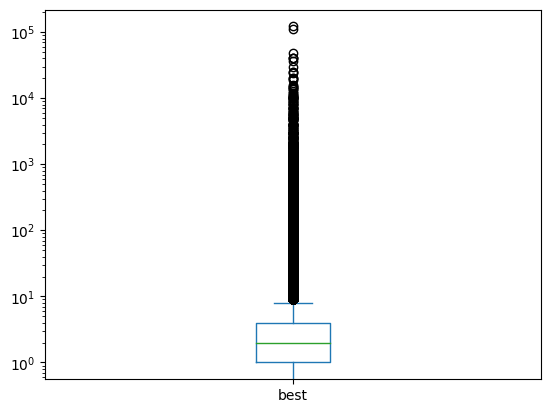

In [487]:
# Distribucion de best
df["best"].plot(kind="box",logy=True)

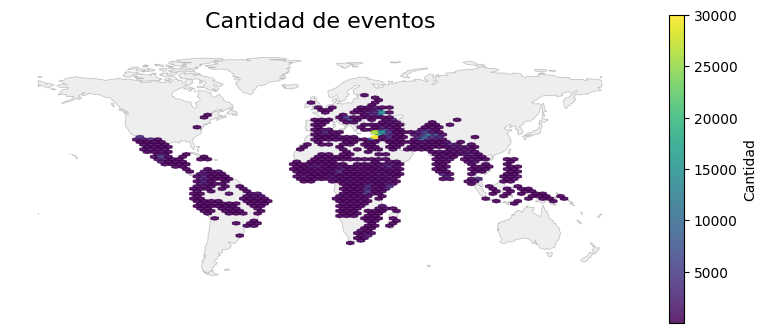

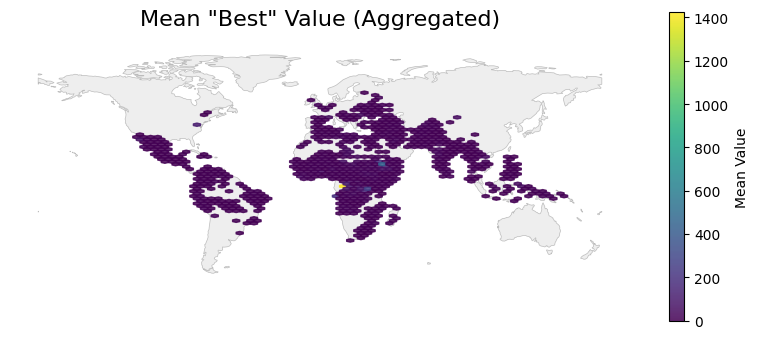

In [488]:
df_geo = df.groupby(['latitude', 'longitude']).agg(
    event_count=('best', 'count'),
    max_best=('best', 'mean')
).reset_index()

# 2. Load the map using the new official package
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
import numpy as np

def plot_larger_groups(column, title, color_map, label, grid_size=40):
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Map background
    world.plot(ax=ax, color='#eeeeee', edgecolor='#bcbcbc', linewidth=0.5)
    
    # Determine how to combine the overlapping points
    # If it's events, we sum them. If it's 'best', we take the mean.
    agg_func = np.sum if column == 'event_count' else np.mean
    
    # Create the Hexbin heatmap
    hb = ax.hexbin(df_geo['longitude'], df_geo['latitude'], 
                   C=df_geo[column], 
                   reduce_C_function=agg_func,
                   gridsize=grid_size, # <-- Decrease this number for BIGGER groups
                   cmap=color_map, 
                   alpha=0.85, 
                   mincnt=1, # Only draw hexagons that have data
                   zorder=3)
    
    plt.colorbar(hb, label=label, shrink=0.4)
    ax.set_title(title, fontsize=16, pad=20)
    
    ax.set_ylim(-60, 85)
    ax.set_axis_off()
    plt.show()

# Test it out! Try changing grid_size to 20 for massive groups, or 60 for smaller ones.
plot_larger_groups('event_count', 'Cantidad de eventos', 'viridis', 'Cantidad', grid_size=60)
plot_larger_groups('max_best', 'Mean "Best" Value (Aggregated)', 'viridis', 'Mean Value', grid_size=60)


## Problema ML

### Objetivos
- Describir el problema de clasificación o de regresión. 
- Definir la variable target.

Una posible aplicacion real asociada a este dataset es la estimacion de las muertes para cuantificar la gravedad del conflicto con el fin de dar soporte a la toma de decisiones rapidas, como pueden ser avisos a cuerpos medicos, militares, evacuaciones, etc. Lo que esto implica es que se desconoceran o no tendran sentido varias columnas del dataset como por ejemplo las que hablan de las fuentes de informacion, ya que estamos asumiendo una situacion en la que el conflicto recien comienza y solo se sabe quien lo reporto, cuando esta ocurriendo, donde y quienes estan implicados.

Un potencial problema con este target esta asociado a la cantidad de outliers que presenta. Una solucion propuesta es la de hacer segmentacion y dividir las muertes en rangos que denoten un grado de emergencia. Esta ultima decision implicaria que estaremos frente a un problema de `clasificacion`, donde la variable target sera `gravedad`

In [489]:
# Creacion de gravedad
best_Q1 = df['best'].quantile(0.25)
best_Q2 = df['best'].quantile(0.5)
best_Q3 = df['best'].quantile(0.75)
print(f"Cuartiles de best: {best_Q1} | {best_Q2} | {best_Q3}")
labels_gravedad = ['baja','media','alta','extrema']

df['gravedad'] = pd.qcut(df['best'], q=4, labels=labels_gravedad)
df['gravedad'].head()

Cuartiles de best: 1.0 | 2.0 | 4.0


0    extrema
1    extrema
2      media
3    extrema
4    extrema
Name: gravedad, dtype: category
Categories (4, object): ['baja' < 'media' < 'alta' < 'extrema']

## Preprocesamiento y Limpieza

### Objetivos
- Realizar una limpieza general del dataset, eliminando o corrigiendo datos 
inconsistentes o irrelevantes. 
- Realizar el split del dataset (ej: train y test).  
- Identificar y tratar los valores faltantes en el dataset.
- Detectar y manejar los outliers utilizando técnicas estadísticas o visuales 
apropiadas. 
- Escalar y / o normalizar los features.

In [490]:
# Primer paso, limpieza de columnas que aportan info redundante o no relevante
cols_to_drop = [
    "id", # No sirve el identificador unico
    "year", # Redundante con date_start
    "type_of_violence", # No considero disponible
    "conflict_name", # No considero disponible
    "relid", # Legacy
    "active_year", # No connsidero relevante si es un conflicto activo
    "code_status", # Siempre es clear
    "conflict_dset_id", # Legacy
    "conflict_new_id", # Mantener solo conflict_name
    "dyad_name", # Redundante con side_a y side_b
    "dyad_dset_id", # Legacy
    "dyad_new_id", # Mantener solo dyad_name
    "side_a_dset_id", # Legacy
    "side_a_new_id", # Usar solo side_a
    "side_b_dset_id", # Legacy
    "side_b_new_id", # Usar solo side_b
    "number_of_sources", #No considero disponible
    "source_article", # No considero disponible
    "source_office", # No considero disponible
    "source_date", #No considero disponible
    "source_headline", #No considero disponible
    "where_description", #No considero patronizable
    "where_prec", #No considero disponible
    "adm_1", # Redundante, con lat long
    "adm_2", # Redundante, con lat long
    "geom_wkt", # Redundante, con lat long
    "priogrid_gid", # Redundante, con lat long
    "country_id", # Usar solo country
    "event_clarity", # No considero disponible
    "date_end", # No considero disponible
    "date_prec", # No considero disponible
    "deaths_a", #Leakage
    "deaths_b", #Leakage
    "deaths_civilians", #Leakage
    "deaths_unknown", #Leakage
    "best", #Leakage
    "high", #Leakage
    "low", #Leakage
    "gwnoa", # Mantener solo side_a
    "gwnob", # Mantener solo side_b
]

small_df = df.drop(columns=cols_to_drop)

#Converison a datetime de la columna date_start
small_df['date_start'] = pd.to_datetime(small_df['date_start'])
small_df.head()

,side_a,side_b,source_original,where_coordinates,latitude,longitude,country,region,date_start,gravedad
0,Government of Iraq,IS,"IS, interior ministry, security source",Kabul city,34.531094,69.162796,Afghanistan,Asia,2017-07-31,extrema
1,Government of Iraq,IS,US officials; Taliban spokesman Zabihullah Muj...,Kabul international airport,34.564444,69.217222,Afghanistan,Asia,2021-08-26,extrema
2,Government of Iraq,IS,US central command spokesperson Captain Bill U...,Jalalabad town,34.428844,70.455750,Afghanistan,Asia,2021-08-28,media
3,Government of Iraq,IS,relative; US Central Command; witnesses; Afgha...,Kabul city,34.531094,69.162796,Afghanistan,Asia,2021-08-29,extrema
4,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,Rebel source,Nangarhar province,34.333330,70.416670,Afghanistan,Asia,1989-01-07,extrema


In [491]:
#Para hacer el split quiero saber antes la distribucion de entradas fecha
small_df["date_start"].dt.year.quantile(0.75)
print(f"Q1 = {small_df["date_start"].dt.year.quantile(0.25)} | Q2 = {small_df["date_start"].dt.year.quantile(0.5)} | Q3 = {small_df["date_start"].dt.year.quantile(0.75)}")

Q1 = 2007.0 | Q2 = 2014.0 | Q3 = 2020.0


In [492]:
# Split 
y1, y2 = 1989, 2019 # Esto seria como hacer un split 75/25   
y3, y4 = 2020, 2024

train = small_df[small_df['date_start'].dt.year.between(y1, y2)].copy()
test = small_df[small_df['date_start'].dt.year.between(y3, y4)].copy()

print(f"Tamano train: {train.shape[0]} | Tamano test: {test.shape[0]} | Relacion {((train.shape[0]*100) / small_df.shape[0]):.2f} %")

Tamano train: 279156 | Tamano test: 106762 | Relacion 72.34 %


In [493]:
# Faltantes
missing_count = train.isna().sum()
missing_percentage = (train.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'Cantidad': missing_count,
    'Porcentaje': missing_percentage
})

# Filtrar las que estan completas
missing_summary = missing_summary[missing_summary['Cantidad'] > 0]

# Ordenar en ascendente
missing_summary = missing_summary.sort_values(by='Cantidad', ascending=False)

missing_summary

,Cantidad,Porcentaje
source_original,38870,13.92


In [494]:
train["source_original"].nunique()

35718

In [495]:
train["source_original"].value_counts().head(50)

source_original
SOHR                                                                   33209
VDC                                                                    25454
police                                                                  9430
Noche y Niebla                                                          8781
SOHR; VDC                                                               8033
SOHR, VDC                                                               6367
SATP                                                                    3757
Balkan Battlegrounds and Bosnian Book of the Dead - List of Victims     3216
Police                                                                  2982
CIDE-PPD                                                                2887
Interior Ministry                                                       2493
Balkan Battlegrounds; Bosnian Book of the Dead                          2235
officials                                                   

In [496]:
#Outliers no deberia tener ahora, ya fueron "tratados" al creal la columna gravedad

In [497]:
#Nada que escalar, no hay numericos

## Feature Engineering

### Objetivos
- Crear nuevos features en caso de ser necesario. Justificar. 
- Aplicar técnicas de conversión de variables: codificación, discretización. 
- Analizar el balance/desbalance de clases (en el caso que se trate de un problema de clasificación). 
- Proponer y aplicar mecanismos de balance en caso de ser necesario y justificar la selección.

In [498]:
#Creacion de features 

#Considero que mas relevante saber el dia y mes que el año

train["mes"] = train["date_start"].dt.month
train["dia"] = train["date_start"].dt.day
train.drop(columns='date_start',inplace=True)
train.head()

,side_a,side_b,source_original,where_coordinates,latitude,longitude,country,region,gravedad,mes,dia
0,Government of Iraq,IS,"IS, interior ministry, security source",Kabul city,34.531094,69.162796,Afghanistan,Asia,extrema,7,31
4,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,Rebel source,Nangarhar province,34.333330,70.416670,Afghanistan,Asia,extrema,1,7
5,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,Kabul radio (monitored in Islamabad),Kunduz province,36.750000,68.750000,Afghanistan,Asia,alta,1,15
6,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,Tass news agency /Western diplomats quoting wi...,Salang pass,35.315833,69.038889,Afghanistan,Asia,extrema,1,23
7,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,Military spokesman,Kabul city,34.531094,69.162796,Afghanistan,Asia,media,1,30


In [499]:
#Codificado y discretizacion

#QUiero antes saber la cantidad de valores unicos para cada categorica
print(f"side_a {train["side_a"].nunique()}")
print(f"side_b {train["side_b"].nunique()}")
print(f"source_original {train["source_original"].nunique()}")
print(f"where_coordinates {train["where_coordinates"].nunique()}")
print(f"country {train["country"].nunique()}")
print(f"region {train["region"].nunique()}")
print(f"gravedad {train["gravedad"].nunique()}")

side_a 851
side_b 846
source_original 35718
where_coordinates 40439
country 122
region 5
gravedad 4


In [500]:
#Para side_a, side_b, source_original, where_coordinates y country
#considero que lo mejor es Hashing por la alta cardinalidad
ct = ColumnTransformer([
    ('country_hash', HashingEncoder(n_components=8), ['country']),
    ('sides_hash', HashingEncoder(n_components=4), ['side_a', 'side_b']),
    ('src_hash', HashingEncoder(n_components=4), ['source_original']),
], remainder='drop')

ct.set_output(transform="pandas")
hashed = ct.fit_transform(train)
train = train.join(hashed)
train.drop(columns=['side_a','side_b','source_original','where_coordinates','country'],inplace=True)

#Para latitude y longitude podemos estandarizar
scaler = StandardScaler()
features_to_scale = ['latitude', 'longitude']
train[features_to_scale] = scaler.fit_transform(train[features_to_scale])

#Region puede ser un one hot por su cardinalidad baja
one_hot = OneHotEncoder(sparse_output=False)  
encoded_array = one_hot.fit_transform(train[["region"]])
columns=one_hot.get_feature_names_out(["region"])
encoded_df = pd.DataFrame(encoded_array, columns=one_hot.get_feature_names_out(["region"]))
train = train.join(encoded_df)
train.drop(columns=["region"],inplace=True)

#Mes y dia debido a su naturaleza ciclica se les puede aplicarr un cyclic encoding
train["mes"] = np.cos(2 * np.pi * train["mes"] / 12)
train["dia"] = np.cos(2 * np.pi * train["mes"] / 31)

#Gravedad es el target asi que label encoding
le = LabelEncoder()
train['gravedad_encoded'] = le.fit_transform(train['gravedad'])
train.drop(columns=['gravedad'],inplace=True)

train.head()

,latitude,longitude,mes,dia,country_hash__col_0,country_hash__col_1,country_hash__col_2,country_hash__col_3,country_hash__col_4,country_hash__col_5,country_hash__col_6,country_hash__col_7,sides_hash__col_0,sides_hash__col_1,sides_hash__col_2,sides_hash__col_3,src_hash__col_0,src_hash__col_1,src_hash__col_2,src_hash__col_3,region_Africa,region_Americas,region_Asia,region_Europe,region_Middle East,gravedad_encoded
0,0.571952,0.762968,-0.866025,0.984634,0,0,0,0,0,0,0,1,1,1,0,0,0,1,0,0,0.0,0.0,1.0,0.0,0.0,2
4,0.558888,0.790854,0.866025,0.984634,0,0,0,0,0,0,0,1,1,1,0,0,1,0,0,0,0.0,0.0,1.0,0.0,0.0,2
5,0.718531,0.753787,0.866025,0.984634,0,0,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0.0,0.0,1.0,0.0,0.0,0
6,0.623791,0.760212,0.866025,0.984634,0,0,0,0,0,0,0,1,1,1,0,0,0,1,0,0,0.0,0.0,1.0,0.0,0.0,2
7,0.571952,0.762968,0.866025,0.984634,0,0,0,0,0,0,0,1,1,1,0,0,1,0,0,0,0.0,0.0,1.0,0.0,0.0,3


<Axes: xlabel='gravedad_encoded'>

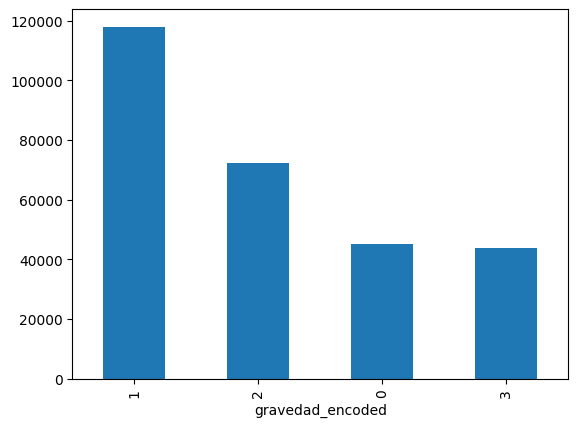

In [ ]:
#Revisamos si hay dessbalance, no deberiamos al haber discretizado gravedad por cuartiles
train['gravedad_encoded'].value_counts().plot(kind='bar')


## Reduccion de Dimensionalidad

### Objetivos
- Evaluar relaciones entre variables y realizar una selección de features con los 
mecanismos vistos en clase (ej: filtros). 
- Implementar técnicas de extracción de features (ej: PCA). Evaluar ventajas y 
desventajas de la reducción. 